**TRAYECTORIA:** *Data Scientist*

**SUBCOMPETENCIA:** Visualización estática de datos

**RETO**: Explorando el índice de felicidad

---

*   NOMBRE: Diego Eduardo Rodríguez Guzmán

---

In [35]:
# Importar las bibliotecas necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1.	Lee el archivo happiness_report.csv para guardar, en un *dataframe* (`happiness`), todos sus registros.

In [36]:
happiness = pd.read_csv('happiness_report.csv')
happiness.head()

,Year,Rank,Country name,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,2024,1,Finland,7.736,1.749,1.783,0.824,0.986,0.110,0.502,1.782
1,2023,143,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672
2,2022,137,Afghanistan,1.859,0.645,0.000,0.087,0.000,0.093,0.059,0.976
3,2021,146,Afghanistan,2.404,0.758,0.000,0.289,0.000,0.089,0.005,1.263
4,2020,150,Afghanistan,2.523,0.370,0.000,0.126,0.000,0.122,0.010,1.895


2. A partir del *dataframe* `happiness` obtén otro (`mexico`) donde únicamente almacenes la información de México. Haz que la columna `Year` quede como índice.

In [37]:
mexico = happiness[happiness['Country name'] == 'Mexico'].set_index('Year')
mexico.head()

,Rank,Country name,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
Year,,,,,,,,,,
2024,10,Mexico,6.979,1.435,1.504,0.550,0.879,0.057,0.118,2.438
2023,25,Mexico,6.678,1.521,1.241,0.544,0.722,0.086,0.127,2.437
2022,36,Mexico,6.330,1.550,1.169,0.389,0.632,0.086,0.115,2.389
2021,46,Mexico,6.128,1.552,0.886,0.623,0.621,0.092,0.115,2.239
2020,37,Mexico,6.317,1.126,0.830,0.634,0.585,0.092,0.089,2.961


3. Obtén un gráfico de línea que muestre cómo ha cambiado el lugar de México en el *ranking* de felicidad a través de los años. Asegúrate de personalizarlo de acuerdo con el formato mostrado en la figura de referencia.

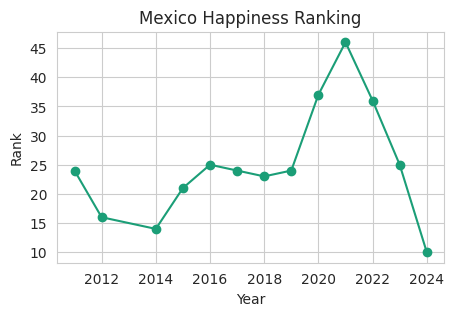

In [38]:
sns.set_style('whitegrid')
sns.set_palette('Dark2')

plt.figure(figsize=(5,3))
plt.plot(mexico.index, mexico['Rank'], marker='o')

plt.title('Mexico Happiness Ranking')
plt.xlabel('Year')
plt.ylabel('Rank')

plt.show()

4. Utiliza la información del 2024 del *dataframe* `mexico` para analizar en qué medida los factores contribuyen a evaluar la felicidad, a través de un gráfico circular.

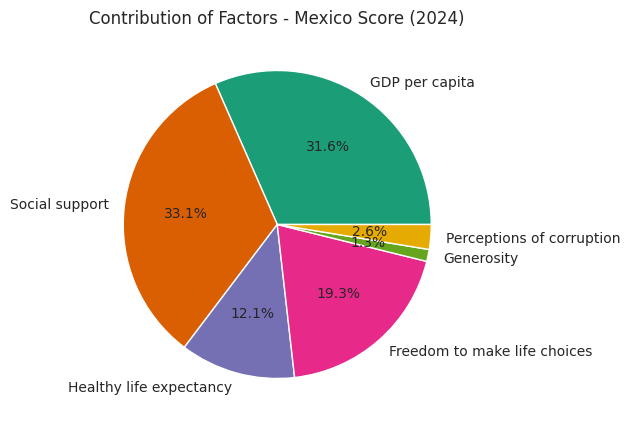

In [39]:
info2024 = mexico.loc[2024, ['GDP per capita', 'Social support', 'Healthy life expectancy',
                                    'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']]

plt.figure(figsize=(5,5))
plt.pie(info2024, labels=info2024.index, autopct='%1.1f%%')
plt.title('Contribution of Factors - Mexico Score (2024)')
plt.show()

5. Filtra el *dataframe* `happiness` para quedarte con la información del 2024 de todos los países (`report2024`). Genera un gráfico de barras para comparar el `Score` del país con mayor felicidad, el de menor puntuación, México y dos economías emergentes similares: Brasil e Indonesia. Incluye el promedio global con una línea horizontal.

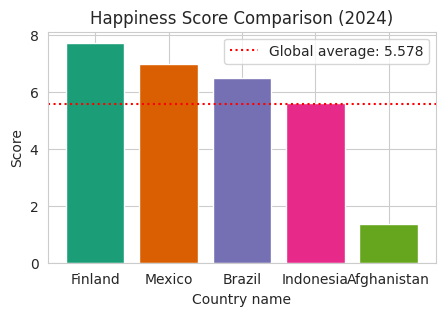

In [40]:
report2024 = happiness[happiness['Year'] == 2024]

pais_max = report2024.loc[report2024['Score'].idxmax(), 'Country name']
pais_min = report2024.loc[report2024['Score'].idxmin(), 'Country name']

paises_comparar = [pais_max, pais_min, 'Mexico', 'Brazil', 'Indonesia']
comparacion = report2024[report2024['Country name'].isin(paises_comparar)]

promedio_global = report2024['Score'].mean()

plt.figure(figsize=(5,3))
plt.bar(comparacion['Country name'], comparacion['Score'], color=sns.color_palette('Dark2'))

plt.axhline(y=promedio_global, color='red', linestyle=':', label=f'Global average: {promedio_global:.3f}')

plt.title('Happiness Score Comparison (2024)')
plt.xlabel('Country name')
plt.ylabel('Score')
plt.legend()
plt.show()

6. Para analizar el impacto de la pandemia en los niveles de felicidad, elabora un gráfico con histogramas superpuestos, correspondientes a los años 2020 y 2024.

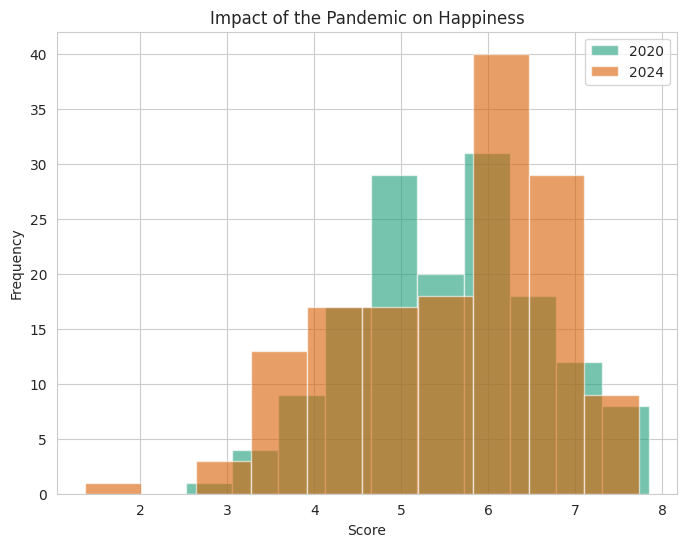

In [41]:
score_2020 = happiness[happiness['Year'] == 2020]['Score']
score_2024 = happiness[happiness['Year'] == 2024]['Score']

plt.figure(figsize=(8,6))
plt.hist(score_2020, alpha=0.6, label='2020')
plt.hist(score_2024, alpha=0.6, label='2024')

plt.title('Impact of the Pandemic on Happiness')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

7. En una misma figura, traza *boxplots* que ilustren la dispersión de los seis factores explicativos de la felicidad en el año 2024.

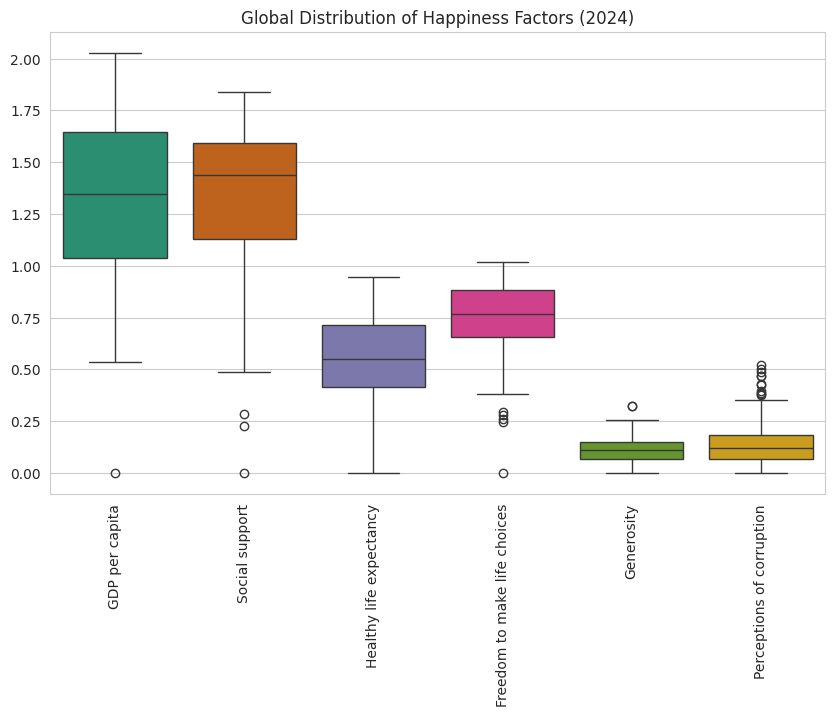

In [42]:
factores = ['GDP per capita', 'Social support', 'Healthy life expectancy',
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

datos_boxplot = report2024[factores]

plt.figure(figsize=(10,6))
sns.boxplot(data=datos_boxplot, palette='Dark2')

plt.title('Global Distribution of Happiness Factors (2024)')
plt.xticks(rotation=90)
plt.show()

8. Crea una matriz de subgráficas de 2 x 3 con *scatter plots* del `Score` versus los seis factores, para determinar qué factor influye más en la felicidad. Configura los ejes para que las marcas del eje `x` se compartan por columna, mientras que cada subgráfica conserve su propio eje `y`.

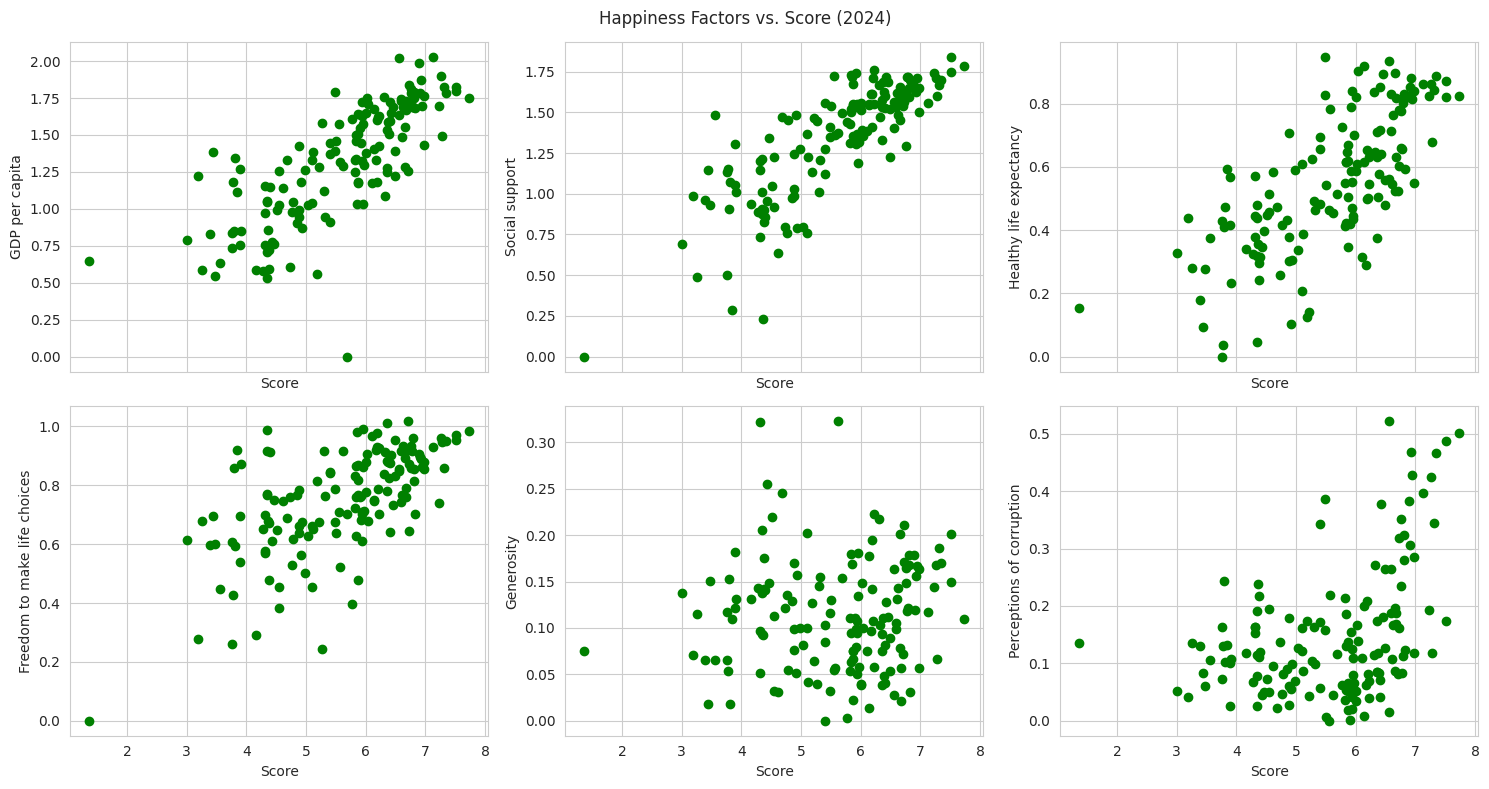

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(15,8), sharex='col')

for i, factor in enumerate(factores):
    fila = i // 3
    columna = i % 3
    ax = axes[fila, columna]
    ax.scatter(report2024['Score'], report2024[factor], color='green')
    ax.set_ylabel(factor)
    ax.set_xlabel('Score')

fig.suptitle('Happiness Factors vs. Score (2024)')
plt.tight_layout()
plt.show()

9. Comprueba lo anterior con un mapa de calor donde incluyas los índices de correlación.

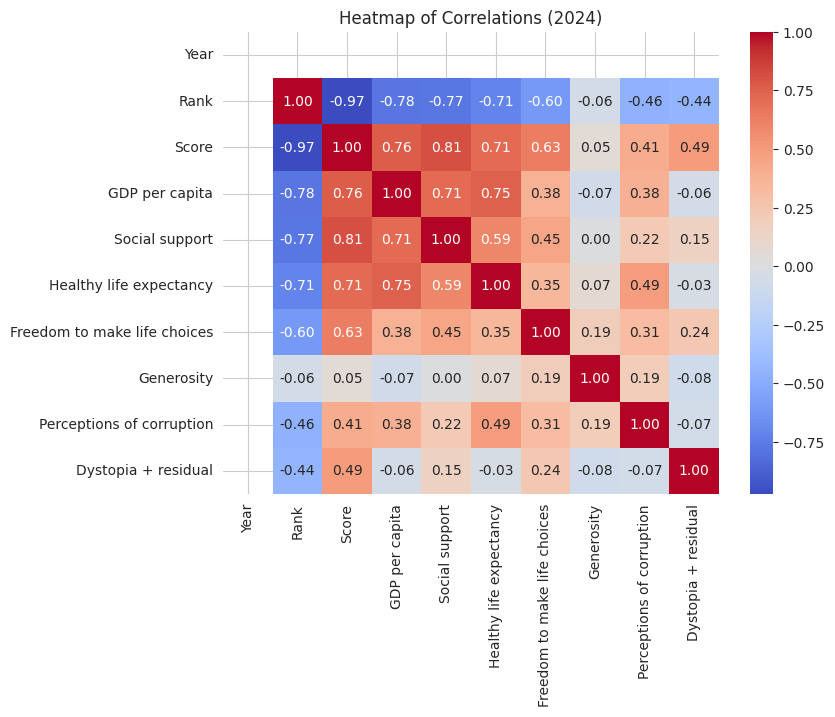

In [44]:
correlaciones = report2024.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Heatmap of Correlations (2024)')
plt.show()

10. Utiliza un gráfico de densidad y contorno para representar la relación entre el PIB per cápita y la esperanza de vida saludable. Señala la posición de México mediante una anotación, procurando que el resultado final mantenga una apariencia similar a la imagen correspondiente.

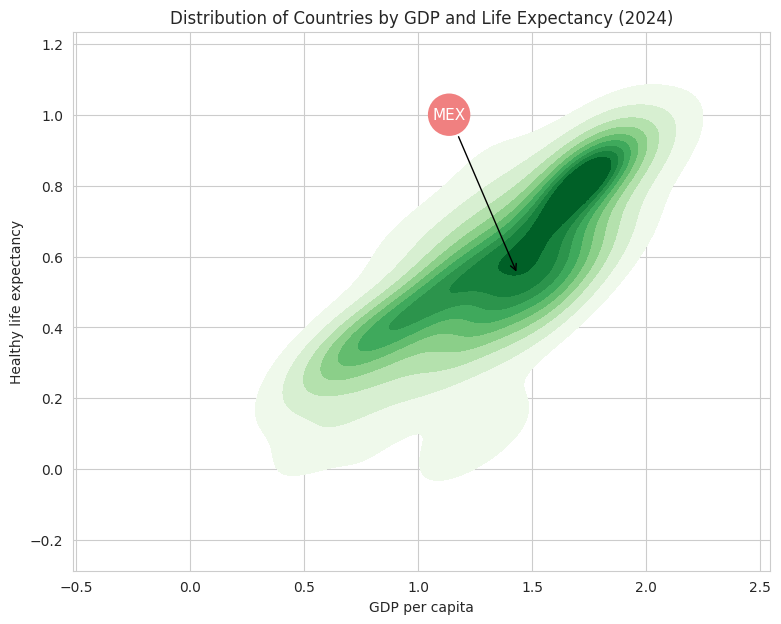

In [45]:
plt.figure(figsize=(9,7))
sns.kdeplot(data=report2024, x='GDP per capita', y='Healthy life expectancy',
            fill=True, cmap='Greens', thresh=0.05)

plt.title('Distribution of Countries by GDP and Life Expectancy (2024)')
plt.xlabel('GDP per capita')
plt.ylabel('Healthy life expectancy')

mex_gdp = report2024[report2024['Country name']=='Mexico']['GDP per capita'].values[0]
mex_life = report2024[report2024['Country name']=='Mexico']['Healthy life expectancy'].values[0]

plt.annotate('MEX', xy=(mex_gdp, mex_life), xytext=(mex_gdp - 0.3, mex_life + 0.45),
             fontsize=11, color='white', ha='center', va='center',
             bbox=dict(boxstyle='circle', fc='lightcoral', ec='none'),
             arrowprops=dict(arrowstyle='->', color='black'))

plt.show()